### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from matplotlib.ticker import FuncFormatter

### Get data from data_processed.csv

In [2]:
df = pd.read_csv("D:\\TAI LIEU DOWNLOAD\\data_processed.csv")

# **PART 3. Question**

##### Before moving on to the question-asking section, we will pose questions related to the available data. Specifically, we will identify the characteristics that influence the decision to purchase products at the pharmacy. We will compare and present these using charts for easier evaluation.

- **Question 1**: In each category, which factor is decisive?
- **Question 2**: In each category, which domestic and foreign products receive more attention?
- **Question 3**: In each category, the distribution of prices.
- **Question 4**: In each category, the distribution of brands.
- **Question 5**: In each category, the distribution of dosage forms.

##### We need to note the importance of the existing rating column. Divide the rating into 2 parts:

- Rated: With all data rated. This will be considered as products that have received attention, users have bought and experienced them, and decided to give feedback.

- Unknown: With all data 'unknown'. This will be considered as products that have not been experienced by users and are not receiving attention.

# **PART 4. Visualization**

## **Question 1**

##### First, we will have an overview of the difference between the number of Rated and Unrated in the attributes.

### **1. Country**

In [3]:
# Top 5 countries have the most counting in the list
top_5_countries = df['Country'].value_counts().head(5)
print(top_5_countries)

# Top 5 countries have the fewest counting in the list
top_5_countries_min = df['Country'].value_counts().tail(5)
print(top_5_countries_min)

Country
Việt Nam    897
Hoa Kỳ      194
Nhật Bản    130
Pháp        127
Úc          101
Name: count, dtype: int64
Country
Slovakia        1
Latvia          1
Cộng hòa Séc    1
Sri Lanka       1
USA             1
Name: count, dtype: int64


After finding the top 5 countries with the highest appearances and the top 5 countries with the lowest appearances, we noticed that for the countries with the least appearances, the number is only 1, so it's impossible to compare the Rated and UnRated levels within them. 

In [4]:
# Count the total occurrences of each country (only keep countries appearing > 2 times)
country_counts = df['Country'].value_counts()[df['Country'].value_counts() > 2]

# Count the number of 'unknown' ratings for each country
unknown_counts = df[df['Rating'] == 'unknown']['Country'].value_counts()

# Count the number of 'rated' ratings (different from 'unknown') for each country
rated_counts = df[df['Rating'] != 'unknown']['Country'].value_counts()

# Ensure countries are only within country_counts
unknown_counts = unknown_counts.reindex(country_counts.index, fill_value=0)
rated_counts = rated_counts.reindex(country_counts.index, fill_value=0)

# Calculate percentages
unknown_percentages = (unknown_counts / country_counts * 100).fillna(0)
rated_percentages = (rated_counts / country_counts * 100).fillna(0)

# Create result DataFrame
result1 = pd.DataFrame({
    'Total': country_counts,
    'Rated Count': rated_counts,
    'Rated %': rated_percentages,
    'Unknown Count': unknown_counts,
    'Unknown %': unknown_percentages
}).sort_values(by='Total', ascending=False)

# Print the result
print(result1)

# Create conditions
rated_greater = result1['Rated %'] > result1['Unknown %']
unknown_greater = result1['Unknown %'] > result1['Rated %']

# Count the number of countries satisfying each condition
count_rated_greater = rated_greater.sum()
count_unknown_greater = unknown_greater.sum()
total_countries = len(result1)

# Calculate percentages
rated_greater_percentage = (count_rated_greater / total_countries) * 100
unknown_greater_percentage = (count_unknown_greater / total_countries) * 100

# Print the results
print(f"Percentage of countries with Rated % greater than Unknown %: {rated_greater_percentage}%")
print(f"Percentage of countries with Unknown % greater than Rated %: {unknown_greater_percentage:.2f}%")


                           Total  Rated Count     Rated %  Unknown Count  \
Country                                                                    
Việt Nam                     897          529   58.974359            368   
Hoa Kỳ                       194          128   65.979381             66   
Nhật Bản                     130          104   80.000000             26   
Pháp                         127           69   54.330709             58   
Úc                           101           70   69.306931             31   
Đức                           75           35   46.666667             40   
Hàn Quốc                      60           29   48.333333             31   
Ý                             58           33   56.896552             25   
Ba Lan                        43           20   46.511628             23   
Thái Lan                      37           26   70.270270             11   
Ấn Độ                         35           15   42.857143             20   
Canada      

- Based on the results above, we can see that most countries have a higher percentage of Rated than Unknown. Therefore, it can be concluded that the country has an influence on the rating.

Country
Việt Nam    897
Hoa Kỳ      194
Nhật Bản    130
Pháp        127
Úc          101
Name: count, dtype: int64


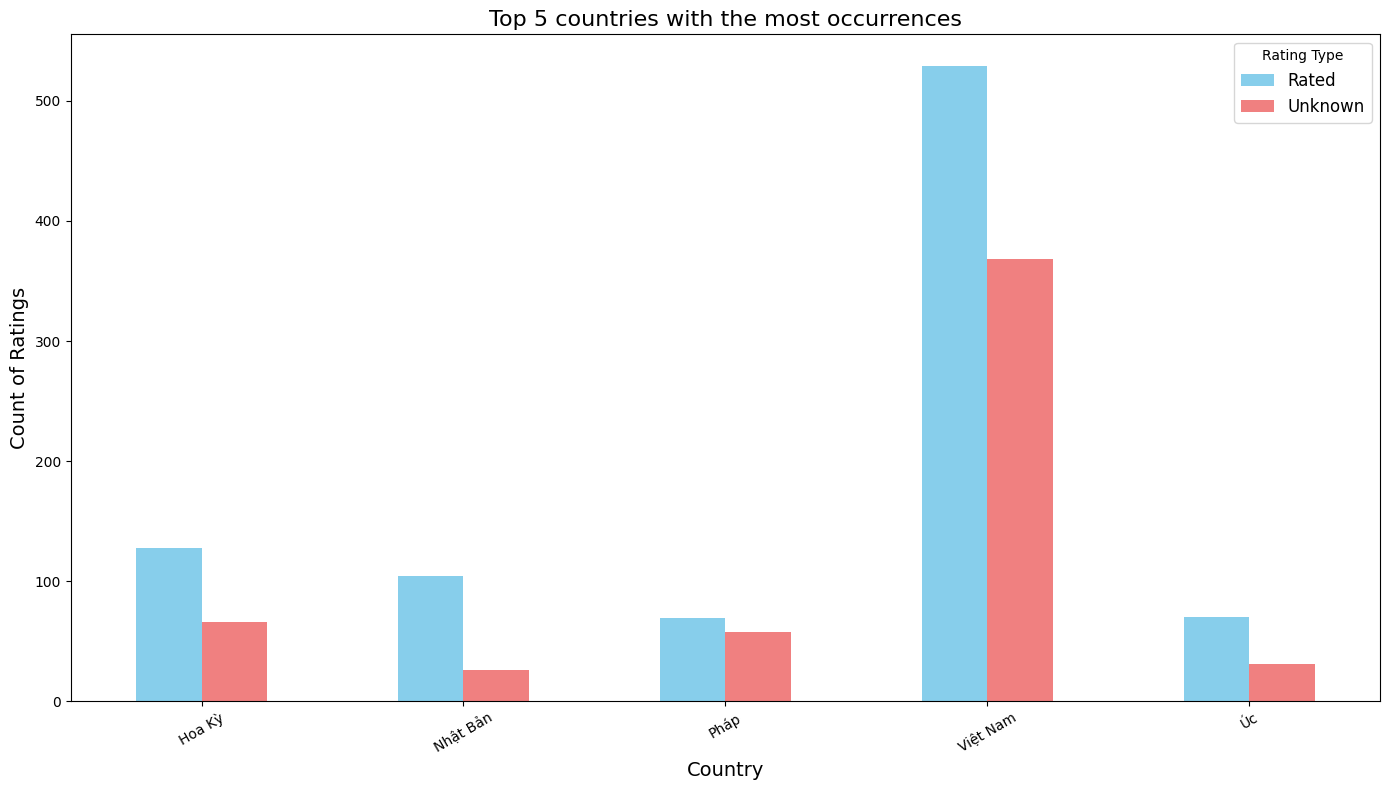

In [5]:
# Get the top 5 countries with the most occurrences
top_5_countries = df['Country'].value_counts().head(5)
print(top_5_countries)

# Create a DataFrame containing only these top 5 countries
top_5_countries_data = df[df['Country'].isin(top_5_countries.index)]

# Filter rated and unrated items
rated_data = top_5_countries_data[top_5_countries_data['Rating'] != 'unknown']
unknown_data = top_5_countries_data[top_5_countries_data['Rating'] == 'unknown']

# Count the number of rated and unrated items in each country
rated_counts = rated_data['Country'].value_counts()
unknown_counts = unknown_data['Country'].value_counts()

# Create a DataFrame from the count results
rating_summary = pd.DataFrame({
    'Rated': rated_counts,
    'Unknown': unknown_counts
}).fillna(0)

# Plot a stacked bar chart
plt.figure(figsize=(14, 8))
rating_summary.plot(kind='bar', color=['skyblue', 'lightcoral'], ax=plt.gca())

# Rotate the x-axis labels 60 degrees
plt.xticks(rotation=30)

# Add title and labels
plt.title('Top 5 countries with the most occurrences', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Count of Ratings', fontsize=14)
plt.legend(title='Rating Type', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()


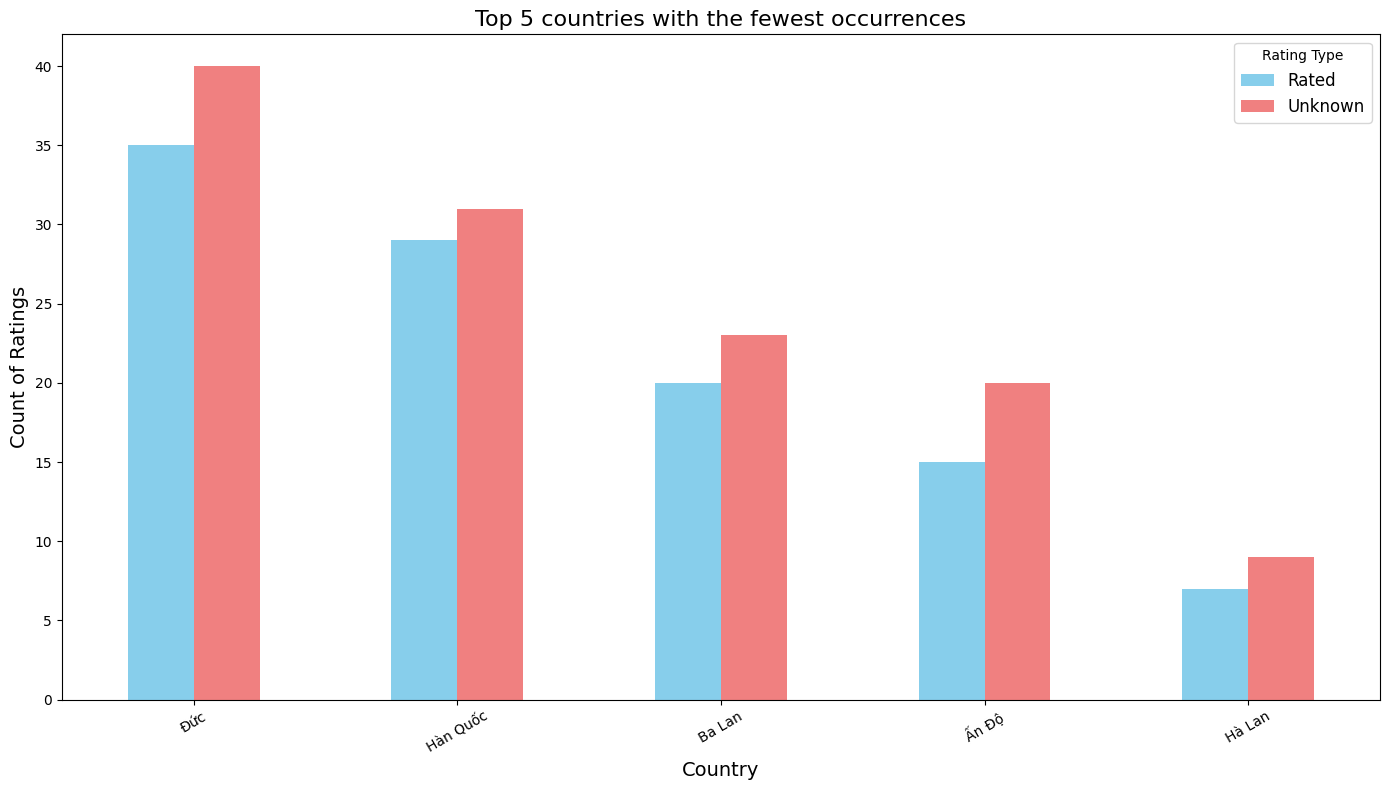

In [6]:
# Filter countries with a count >= 2
filtered_countries = df['Country'].value_counts()
filtered_countries = filtered_countries[filtered_countries > 2]

# Create a DataFrame containing only the filtered countries
filtered_countries_data = df[df['Country'].isin(filtered_countries.index)]

# Filter rated and unrated items
rated_data = filtered_countries_data[filtered_countries_data['Rating'] != 'unknown']
unknown_data = filtered_countries_data[filtered_countries_data['Rating'] == 'unknown']

# Count the number of rated and unrated items in each country
rated_counts = rated_data['Country'].value_counts()
unknown_counts = unknown_data['Country'].value_counts()

# Create a DataFrame from the count results
rating_summary = pd.DataFrame({
    'Rated': rated_counts,
    'Unknown': unknown_counts
}).fillna(0)

# Select only the top 5 countries where "unknown" count is greater than "Rated" count
top_5_countries_unknown_more = rating_summary[rating_summary['Unknown'] > rating_summary['Rated']].nlargest(5, 'Unknown')

# Plot a stacked bar chart
plt.figure(figsize=(14, 8))
top_5_countries_unknown_more.plot(kind='bar', color=['skyblue', 'lightcoral'], ax=plt.gca())

# Rotate the x-axis labels 60 degrees
plt.xticks(rotation=30)

# Add title and labels
plt.title('Top 5 countries with the fewest occurrences', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Count of Ratings', fontsize=14)
plt.legend(title='Rating Type', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()


### **2. Trademark**

In [7]:
# Top 5 trademarks have the most counting in the list
top_5_trademarks = df['Trademark'].value_counts().head(5)
print(top_5_trademarks)

# Top 5 trademarks have the fewest counting in the list
top_5_trademarks_min = df['Trademark'].value_counts().tail(5)
print(top_5_trademarks_min)

Trademark
Kingphar    185
Eucerin      62
Jpanwell     35
Abbott       30
Nam Dược     27
Name: count, dtype: int64
Trademark
Oribe                 1
Samsam                1
Martinez Nieto S.A    1
Dakvin                1
Eagle                 1
Name: count, dtype: int64


After finding the top 5 trademarks with the highest appearances and the top 5 trademarks with the lowest appearances, we noticed that for the trademarks with the least appearances, the number is only 1, so it's impossible to compare the Rated and UnRated levels within them. 

In [8]:
# Count the total occurrences of each trademark (only keep trademarks appearing > 2 times)
trademark_counts = df['Trademark'].value_counts()[df['Trademark'].value_counts() > 2]

# Count the number of 'unknown' ratings for each trademark
unknown_counts = df[df['Rating'] == 'unknown']['Trademark'].value_counts()

# Count the number of 'rated' ratings (different from 'unknown') for each trademark
rated_counts = df[df['Rating'] != 'unknown']['Trademark'].value_counts()

# Ensure trademarks are only within trademark_counts
unknown_counts = unknown_counts.reindex(trademark_counts.index, fill_value=0)
rated_counts = rated_counts.reindex(trademark_counts.index, fill_value=0)

# Calculate percentages
unknown_percentages = (unknown_counts / trademark_counts * 100).fillna(0)
rated_percentages = (rated_counts / trademark_counts * 100).fillna(0)

# Create result DataFrame
result2 = pd.DataFrame({
    'Total': trademark_counts,
    'Rated Count': rated_counts,
    'Rated %': rated_percentages,
    'Unknown Count': unknown_counts,
    'Unknown %': unknown_percentages
}).sort_values(by='Total', ascending=False)

# Print the result
print(result2)

# Create conditions
rated_greater = result2['Rated %'] > result2['Unknown %']
unknown_greater = result2['Unknown %'] > result2['Rated %']

# Count the number of trademarks satisfying each condition
count_rated_greater = rated_greater.sum()
count_unknown_greater = unknown_greater.sum()
total_countries = len(result2)

# Calculate percentages
rated_greater_percentage = (count_rated_greater / total_countries) * 100
unknown_greater_percentage = (count_unknown_greater / total_countries) * 100

# Print the results
print(f"Percentage of trademarks with Rated % greater than Unknown %: {rated_greater_percentage}%")
print(f"Percentage of trademarks with Unknown % greater than Rated %: {unknown_greater_percentage:.2f}%")


             Total  Rated Count    Rated %  Unknown Count  Unknown %
Trademark                                                           
Kingphar       185           92  49.729730             93  50.270270
Eucerin         62           21  33.870968             41  66.129032
Jpanwell        35           33  94.285714              2   5.714286
Abbott          30           22  73.333333              8  26.666667
Nam Dược        27           17  62.962963             10  37.037037
...            ...          ...        ...            ...        ...
Ladophar         3            2  66.666667              1  33.333333
Gpharm           3            2  66.666667              1  33.333333
Á Châu           3            2  66.666667              1  33.333333
NanoFrance       3            1  33.333333              2  66.666667
Mediplantex      3            2  66.666667              1  33.333333

[182 rows x 5 columns]
Percentage of trademarks with Rated % greater than Unknown %: 65.93406593406593

- Based on the results above, we can see that most trademark have a higher percentage of Rated than Unknown. Therefore, it can be concluded that the country has an influence on the rating.

Trademark
Kingphar    185
Eucerin      62
Jpanwell     35
Abbott       30
Nam Dược     27
Name: count, dtype: int64


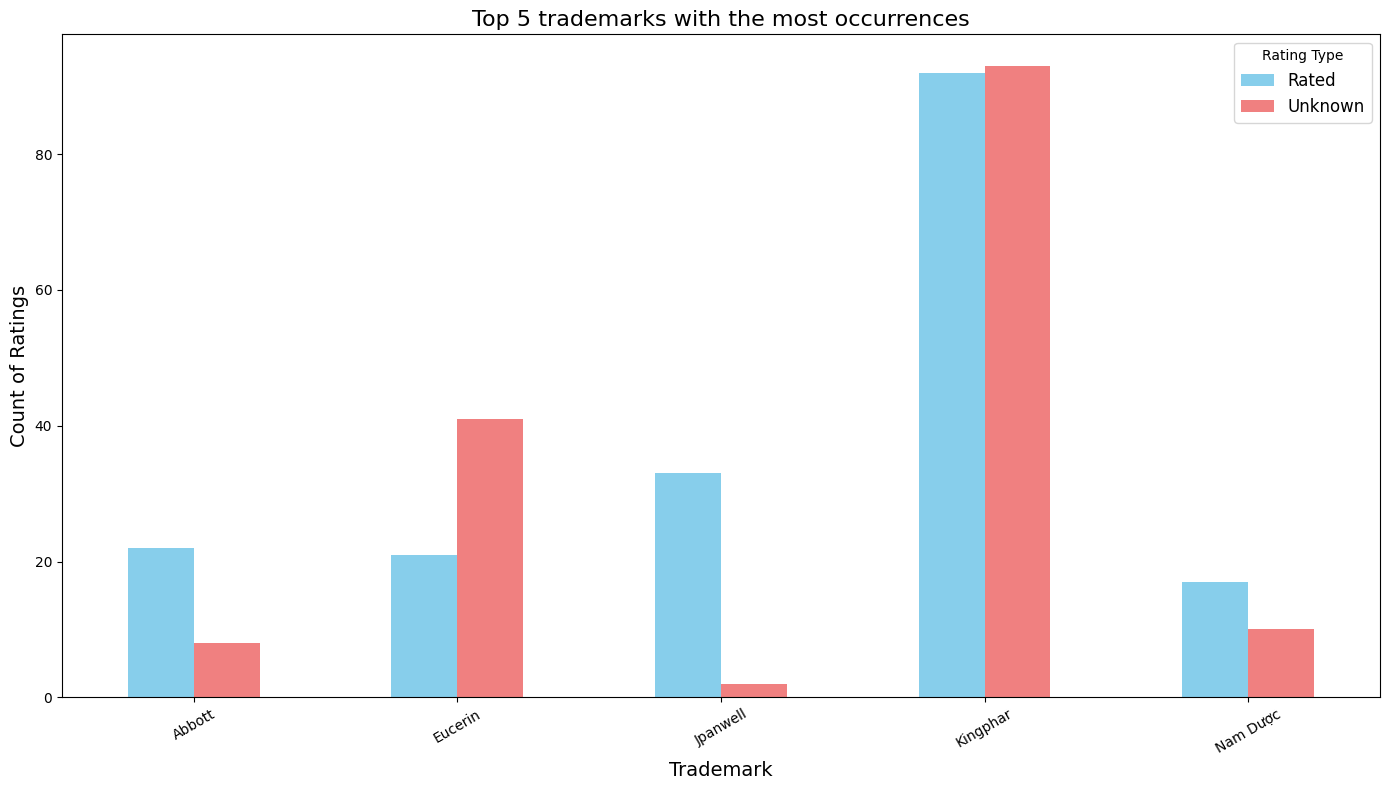

In [9]:
# Get the top 5 trademarks with the most occurrences
top_5_trademark = df['Trademark'].value_counts().head(5)
print(top_5_trademark)

# Create a DataFrame containing only these top 5 trademarks
top_5_trademark_data = df[df['Trademark'].isin(top_5_trademark.index)]

# Filter rated and unrated items
rated_data = top_5_trademark_data[top_5_trademark_data['Rating'] != 'unknown']
unknown_data = top_5_trademark_data[top_5_trademark_data['Rating'] == 'unknown']

# Count the number of rated and unrated items in each trademark
rated_counts = rated_data['Trademark'].value_counts()
unknown_counts = unknown_data['Trademark'].value_counts()

# Create a DataFrame from the count results
rating_summary = pd.DataFrame({
    'Rated': rated_counts,
    'Unknown': unknown_counts
}).fillna(0)

# Plot a stacked bar chart
plt.figure(figsize=(14, 8))
rating_summary.plot(kind='bar', color=['skyblue', 'lightcoral'], ax=plt.gca())

# Rotate the x-axis labels 60 degrees
plt.xticks(rotation=30)

# Add title and labels
plt.title('Top 5 trademarks with the most occurrences', fontsize=16)
plt.xlabel('Trademark', fontsize=14)
plt.ylabel('Count of Ratings', fontsize=14)
plt.legend(title='Rating Type', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()


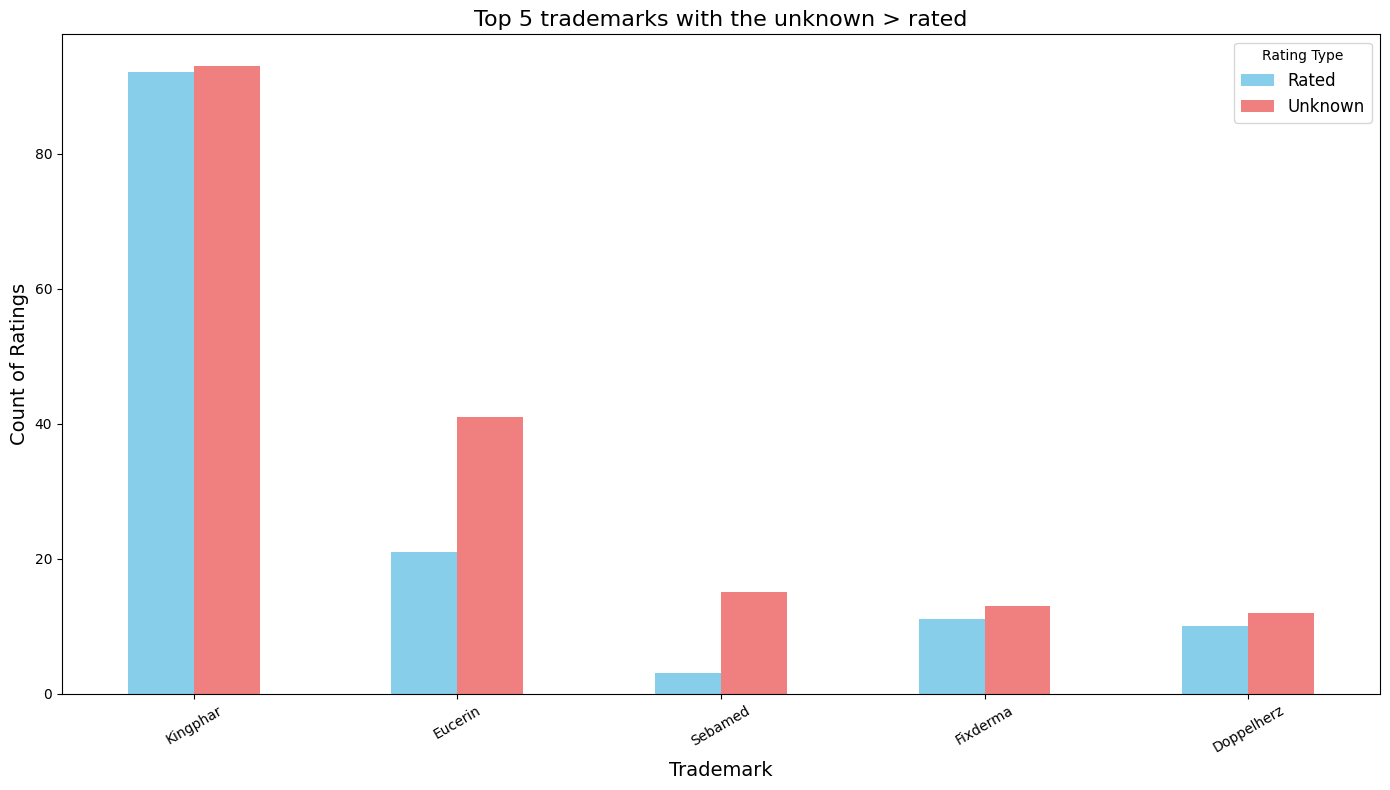

In [10]:
# Filter trademarks with a count >= 2
filtered_trademark = df['Trademark'].value_counts()
filtered_trademark = filtered_trademark[filtered_trademark > 2]

# Create a DataFrame containing only the filtered trademarks
filtered_trademark_data = df[df['Trademark'].isin(filtered_trademark.index)]

# Filter rated and unrated items
rated_data = filtered_trademark_data[filtered_trademark_data['Rating'] != 'unknown']
unknown_data = filtered_trademark_data[filtered_trademark_data['Rating'] == 'unknown']

# Count the number of rated and unrated items in each trademark
rated_counts = rated_data['Trademark'].value_counts()
unknown_counts = unknown_data['Trademark'].value_counts()

# Create a DataFrame from the count results
rating_summary = pd.DataFrame({
    'Rated': rated_counts,
    'Unknown': unknown_counts
}).fillna(0)

# Select only the top 5 trademarks where "unknown" count is greater than "Rated" count
top_5_trademark_unknown_more = rating_summary[rating_summary['Unknown'] > rating_summary['Rated']].nlargest(5, 'Unknown')

# Plot a stacked bar chart
plt.figure(figsize=(14, 8))
top_5_trademark_unknown_more.plot(kind='bar', color=['skyblue', 'lightcoral'], ax=plt.gca())

# Rotate the x-axis labels 60 degrees
plt.xticks(rotation=30)

# Add title and labels
plt.title('Top 5 trademarks with the unknown > rated', fontsize=16)
plt.xlabel('Trademark', fontsize=14)
plt.ylabel('Count of Ratings', fontsize=14)
plt.legend(title='Rating Type', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()


### **3. Price**

- As for the Price attribute columns, we will divide it into many different value groups and see the analysis of Rating and Unknown according to each price level.

Price_Category
0-300k       1420
300k-600k     417
600k-900k      92
900k-1.2m      41
1.2m+          29
Name: count, dtype: int64


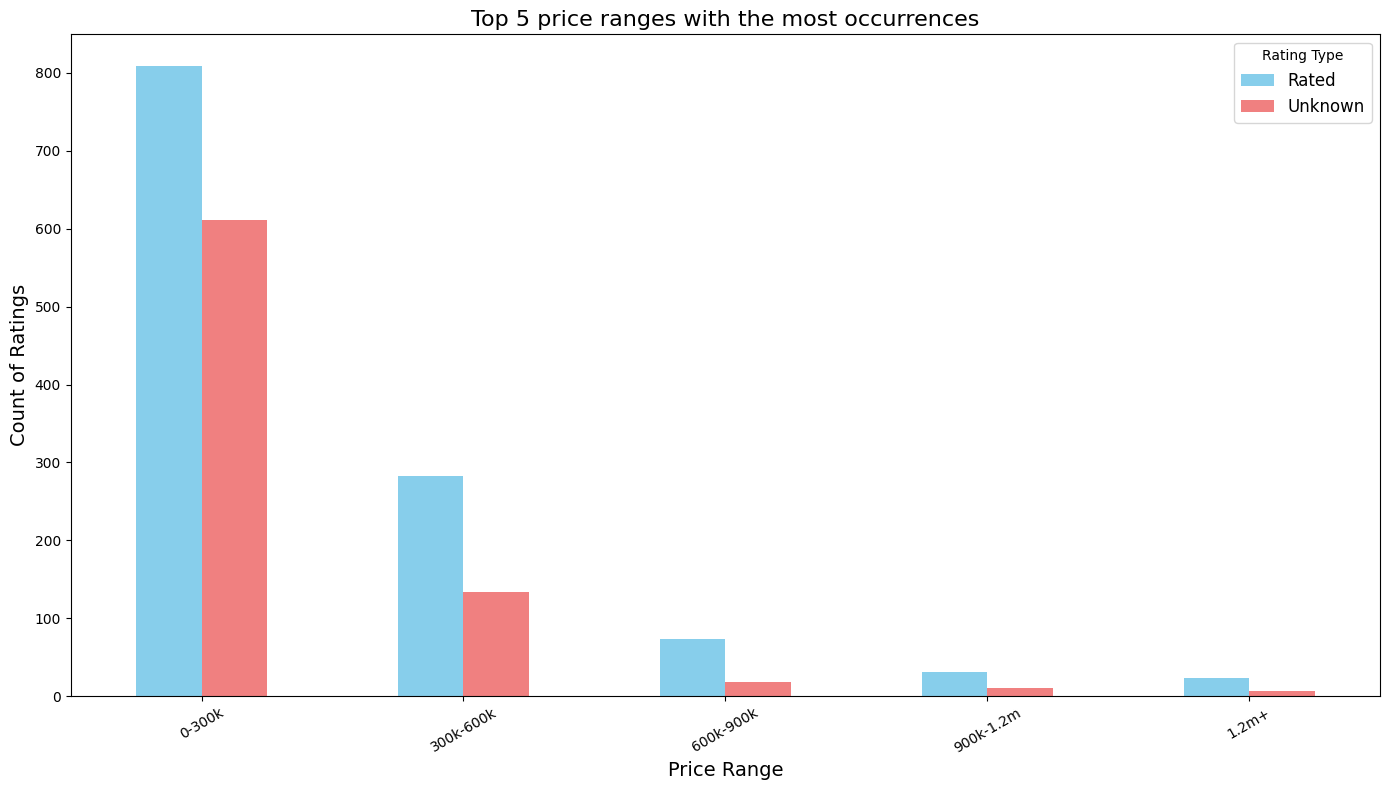

In [11]:
# Add a new column to categorize price ranges
bins = [0, 300000, 600000, 900000, 1200000, float('inf')]
labels = ['0-300k', '300k-600k', '600k-900k', '900k-1.2m', '1.2m+']
df['Price_Category'] = pd.cut(df['Price'], bins=bins, labels=labels, right=False)

# Get the top 5 price ranges with the most occurrences
top_5_price_categories = df['Price_Category'].value_counts().head(5)
print(top_5_price_categories)

# Create a DataFrame containing only these top 5 price ranges
top_5_price_categories_data = df[df['Price_Category'].isin(top_5_price_categories.index)]

# Filter rated and unrated items
rated_data = top_5_price_categories_data[top_5_price_categories_data['Rating'] != 'unknown']
unknown_data = top_5_price_categories_data[top_5_price_categories_data['Rating'] == 'unknown']

# Count the number of rated and unrated items in each price range
rated_counts = rated_data['Price_Category'].value_counts()
unknown_counts = unknown_data['Price_Category'].value_counts()

# Create a DataFrame from the count results
rating_summary = pd.DataFrame({
    'Rated': rated_counts,
    'Unknown': unknown_counts
}).fillna(0)

# Plot a stacked bar chart
plt.figure(figsize=(14, 8))
rating_summary.plot(kind='bar', color=['skyblue', 'lightcoral'], ax=plt.gca())

# Rotate the x-axis labels 60 degrees
plt.xticks(rotation=30)

# Add title and labels
plt.title('Top 5 price ranges with the most occurrences', fontsize=16)
plt.xlabel('Price Range', fontsize=14)
plt.ylabel('Count of Ratings', fontsize=14)
plt.legend(title='Rating Type', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()


- In the image above, it can be seen that at every price level, the number of Rated products is always greater than Unknown.

### **4. Dosage Form**

In [12]:
# Count the total occurrences of each dosage form (only keep dosage forms appearing > 2 times)
Dosage_counts = df['Dosage Form'].value_counts()[df['Dosage Form'].value_counts() > 2]

# Count the number of 'unknown' ratings for each dosage form
unknown_counts = df[df['Rating'] == 'unknown']['Dosage Form'].value_counts()

# Count the number of 'rated' ratings (different from 'unknown') for each dosage form
rated_counts = df[df['Rating'] != 'unknown']['Dosage Form'].value_counts()

# Ensure dosage forms are only within dosage_counts
unknown_counts = unknown_counts.reindex(Dosage_counts.index, fill_value=0)
rated_counts = rated_counts.reindex(Dosage_counts.index, fill_value=0)

# Calculate percentages
unknown_percentages = (unknown_counts / Dosage_counts * 100).fillna(0)
rated_percentages = (rated_counts / Dosage_counts * 100).fillna(0)

# Create result DataFrame
result3 = pd.DataFrame({
    'Total': Dosage_counts,
    'Rated Count': rated_counts,
    'Rated %': rated_percentages,
    'Unknown Count': unknown_counts,
    'Unknown %': unknown_percentages
}).sort_values(by='Total', ascending=False)

# Print the results
print(result3)

# Create conditions
rated_greater = result3['Rated %'] > result3['Unknown %']
unknown_greater = result3['Unknown %'] > result3['Rated %']

# Count the number of dosage forms satisfying each condition
count_rated_greater = rated_greater.sum()
count_unknown_greater = unknown_greater.sum()
total_countries = len(result3)

# Calculate percentages
rated_greater_percentage = (count_rated_greater / total_countries) * 100
unknown_greater_percentage = (count_unknown_greater / total_countries) * 100

# Print the results
print(f"Percentage of dosage forms with Rated % greater than Unknown %: {rated_greater_percentage}%")
print(f"Percentage of dosage forms with Unknown % greater than Rated %: {unknown_greater_percentage:.2f}%")


                        Total  Rated Count    Rated %  Unknown Count  \
Dosage Form                                                            
Dạng kem                  447          256  57.270694            191   
Viên nén                  346          190  54.913295            156   
Viên nang                 231          155  67.099567             76   
Dung dịch                 189          110  58.201058             79   
Viên nang mềm             172          108  62.790698             64   
Dạng bột                  128           75  58.593750             53   
Viên nang cứng            125           93  74.400000             32   
Siro                       57           43  75.438596             14   
Viên nén bao phim          52           35  67.307692             17   
Dung dịch uống             39           33  84.615385              6   
Viên sủi                   35           24  68.571429             11   
Cốm                        30           20  66.666667           

- Based on the results above, we can see that most Dosage Form have a higher percentage of Rated than Unknown. Therefore, it can be concluded that the country has an influence on the rating.

Dosage Form
Dạng kem         447
Viên nén         346
Viên nang        231
Dung dịch        189
Viên nang mềm    172
Name: count, dtype: int64


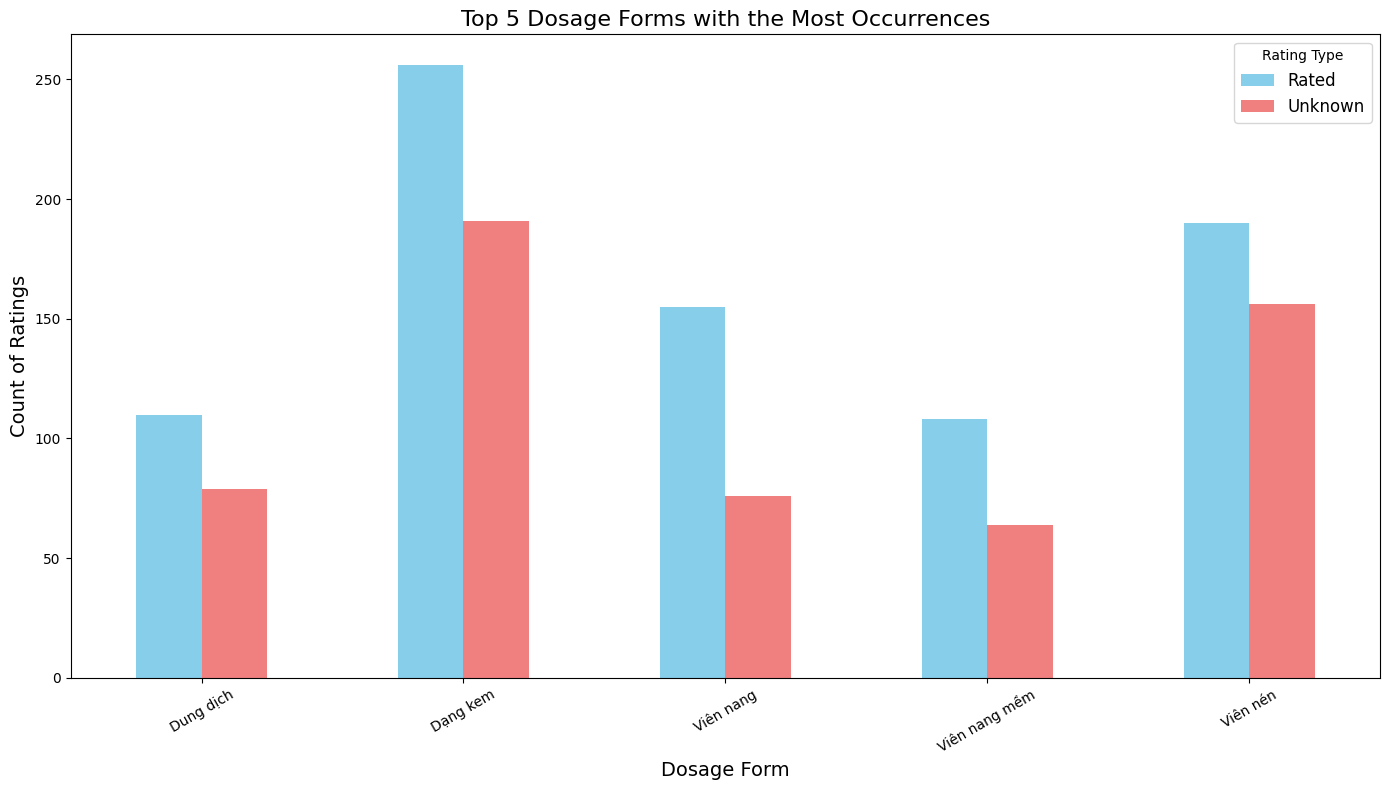

In [13]:
# Get the top 5 dosage forms with the most occurrences
top_5_dosage = df['Dosage Form'].value_counts().head(5)
print(top_5_dosage)

# Create a DataFrame containing only these top 5 dosage forms
top_5_dosages_data = df[df['Dosage Form'].isin(top_5_dosage.index)]

# Filter rated and unrated items
rated_data = top_5_dosages_data[top_5_dosages_data['Rating'] != 'unknown']
unknown_data = top_5_dosages_data[top_5_dosages_data['Rating'] == 'unknown']

# Count the number of rated and unrated items in each dosage form
rated_counts = rated_data['Dosage Form'].value_counts()
unknown_counts = unknown_data['Dosage Form'].value_counts()

# Create a DataFrame from the count results
rating_summary = pd.DataFrame({
    'Rated': rated_counts,
    'Unknown': unknown_counts
}).fillna(0)

# Plot a stacked bar chart
plt.figure(figsize=(14, 8))
rating_summary.plot(kind='bar', color=['skyblue', 'lightcoral'], ax=plt.gca())

# Rotate the x-axis labels 60 degrees
plt.xticks(rotation=30)

# Add title and labels
plt.title('Top 5 Dosage Forms with the Most Occurrences', fontsize=16)
plt.xlabel('Dosage Form', fontsize=14)
plt.ylabel('Count of Ratings', fontsize=14)
plt.legend(title='Rating Type', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()


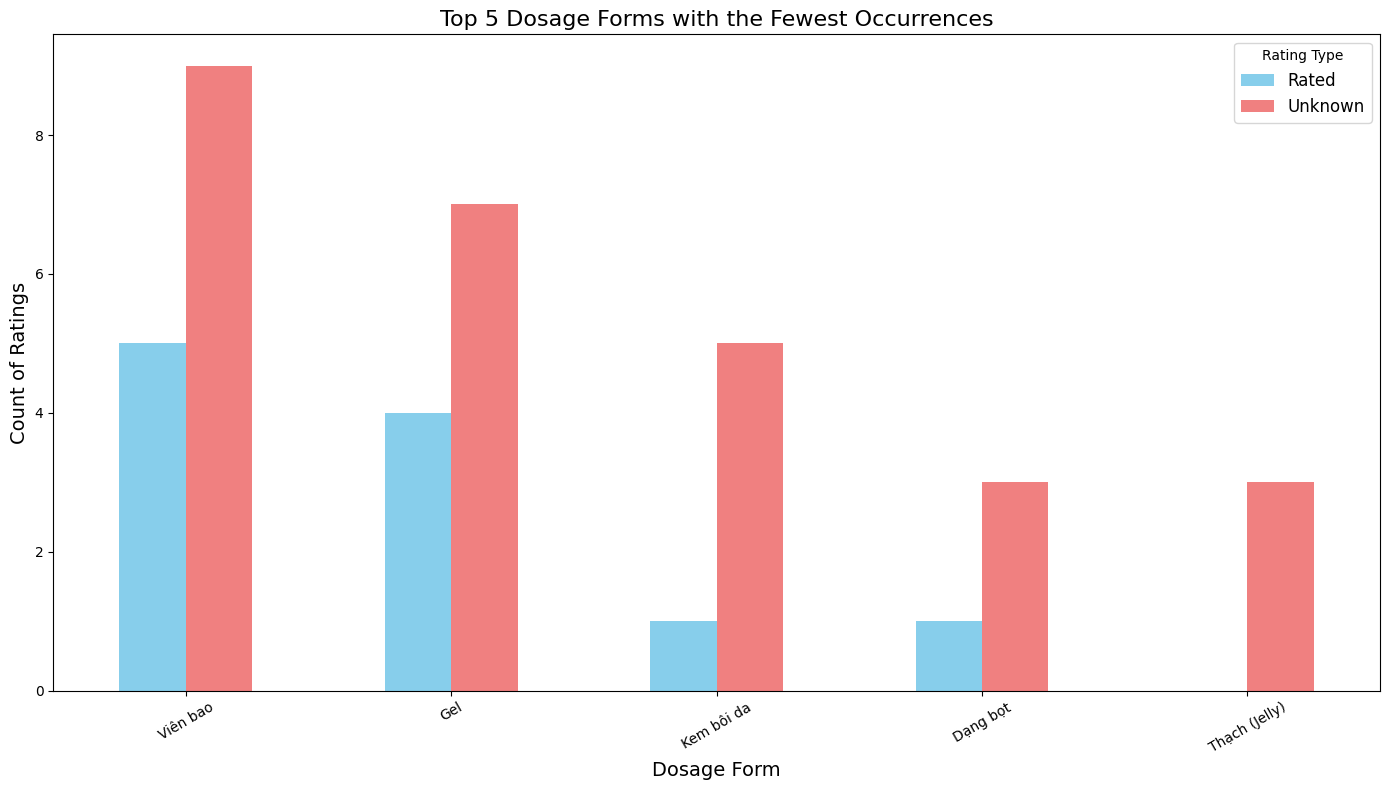

In [14]:
# Filter dosage forms with a count >= 2
filtered_dosages = df['Dosage Form'].value_counts()
filtered_dosages = filtered_dosages[filtered_dosages >= 2]

# Create a DataFrame containing only the filtered dosage forms
filtered_dosages_data = df[df['Dosage Form'].isin(filtered_dosages.index)]

# Filter rated and unrated items
rated_data = filtered_dosages_data[filtered_dosages_data['Rating'] != 'unknown']
unknown_data = filtered_dosages_data[filtered_dosages_data['Rating'] == 'unknown']

# Count the number of rated and unrated items in each dosage form
rated_counts = rated_data['Dosage Form'].value_counts()
unknown_counts = unknown_data['Dosage Form'].value_counts()

# Create a DataFrame from the count results
rating_summary = pd.DataFrame({
    'Rated': rated_counts,
    'Unknown': unknown_counts
}).fillna(0)

# Select only the top 5 dosage forms where "unknown" count is greater than "Rated" count
top_5_dosage_unknown_more = rating_summary[rating_summary['Unknown'] > rating_summary['Rated']].nlargest(5, 'Unknown')

# Plot a stacked bar chart
plt.figure(figsize=(14, 8))
top_5_dosage_unknown_more.plot(kind='bar', color=['skyblue', 'lightcoral'], ax=plt.gca())

# Rotate the x-axis labels 60 degrees
plt.xticks(rotation=30)

# Add title and labels
plt.title('Top 5 Dosage Forms with the Fewest Occurrences', fontsize=16)
plt.xlabel('Dosage Form', fontsize=14)
plt.ylabel('Count of Ratings', fontsize=14)
plt.legend(title='Rating Type', fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()


#### **To summarize**: 
- We have checked the 4 attributes Country, Trademark, Price, Dosage Form. All 44 attributes show a rating rate much higher than the rate of unknown.
- In sentence 1, for each attribute we will have 2 images to visualize, image 1 will be the top 5 appearing most in that attribute, and through all 4 first images of the 4 attributes we see a large rating rate more than Unknown. In the second image, we will select the top 5 in the Unknown group. This is to better understand the Unknown attribute. And give us a more general overview.
- Starting from question 2, we will clarify the influence of each attribute in the categories.

## **Question 2**

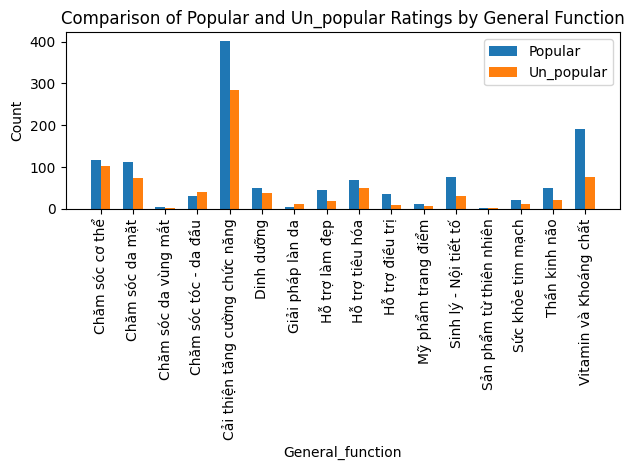

In [15]:
function_popular_count = df.groupby('General_function').agg(
    popular=('Rating', lambda x: (x != 'unknown').sum()),
    un_popular=('Rating', lambda x: (x == 'unknown').sum())
).reset_index()

# Set up the position of each group of bars
index = np.arange(len(function_popular_count['General_function']))
bar_width = 0.3

# Set up the plot
fig, ax = plt.subplots()

# Plot the bars 'popular' and 'un_popular'
bar1 = ax.bar(index - bar_width/2, function_popular_count['popular'], bar_width, label='Popular')
bar2 = ax.bar(index + bar_width/2, function_popular_count['un_popular'], bar_width, label='Un_popular')

# Set up the title and labels
ax.set_xlabel('General_function')
ax.set_ylabel('Count')
ax.set_title('Comparison of Popular and Un_popular Ratings by General Function')
ax.set_xticks(index)
ax.set_xticklabels(function_popular_count['General_function'], rotation=90)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


In [16]:
#Count Popular = VietNam + Other_Countries
country_general_popular = df.groupby('General_function').agg(
    Popular=('Rating', lambda x: (x != 'unknown').sum()),
    Vietnam=('Country', lambda x: ((x == 'Việt Nam') & (df['Rating'] != 'unknown')).sum()),
    Other_Countries=('Country', lambda x: ((x != 'Việt Nam') & (df['Rating'] != 'unknown')).sum())
).reset_index()


print(country_general_popular)



                  General_function  Popular  Vietnam  Other_Countries
0                  Chăm sóc cơ thể      116       49               67
1                  Chăm sóc da mặt      113       32               81
2             Chăm sóc da vùng mắt        4        0                4
3            Chăm sóc tóc - da đầu       31       26                5
4   Cải thiện tăng cường chức năng      402      207              195
5                       Dinh dưỡng       51       14               37
6                 Giải pháp làn da        4        2                2
7                   Hỗ trợ làm đẹp       46       19               27
8                  Hỗ trợ tiêu hóa       68       38               30
9                  Hỗ trợ điều trị       35       23               12
10              Mỹ phẩm trang điểm       12        3                9
11           Sinh lý - Nội tiết tố       75       37               38
12         Sản phẩm từ thiên nhiên        2        2                0
13               Sức

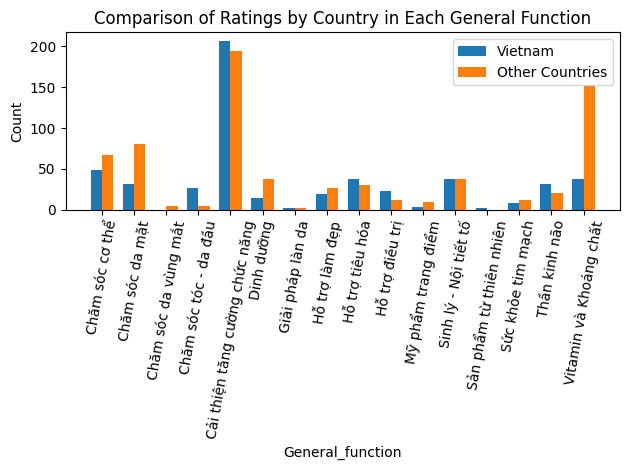

In [17]:
# Set up the position of each group of bars
index = np.arange(len(country_general_popular['General_function']))
bar_width = 0.35

# Set up the plot
fig, ax = plt.subplots()

# Plot the bars 'Vietnam' and 'Other_Countries'
bar1 = ax.bar(index - bar_width/2, country_general_popular['Vietnam'], bar_width, label='Vietnam')
bar2 = ax.bar(index + bar_width/2, country_general_popular['Other_Countries'], bar_width, label='Other Countries')

# Set up the title and labels
ax.set_xlabel('General_function')
ax.set_ylabel('Count')
ax.set_title('Comparison of Ratings by Country in Each General Function')
ax.set_xticks(index)
ax.set_xticklabels(country_general_popular['General_function'], rotation=80)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


#### **To summarize**: 
- For the categories of products that are of interest, there is no clear distinction in product ratings between Vietnam and other countries. Except for the "Vitamin và khoáng chất" category, which indicates that when purchasing vitamin products, users tend to trust foreign products more than those from Vietnam.
- This shows that at drug distributors in Vietnam, products coming to Vietnam will account for a larger quantity than foreign products.

## **Question 3**

C:\Users\Admin\AppData\Local\Temp\ipykernel_21212\3473474743.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby(['General_function', 'Price_Category']).agg(


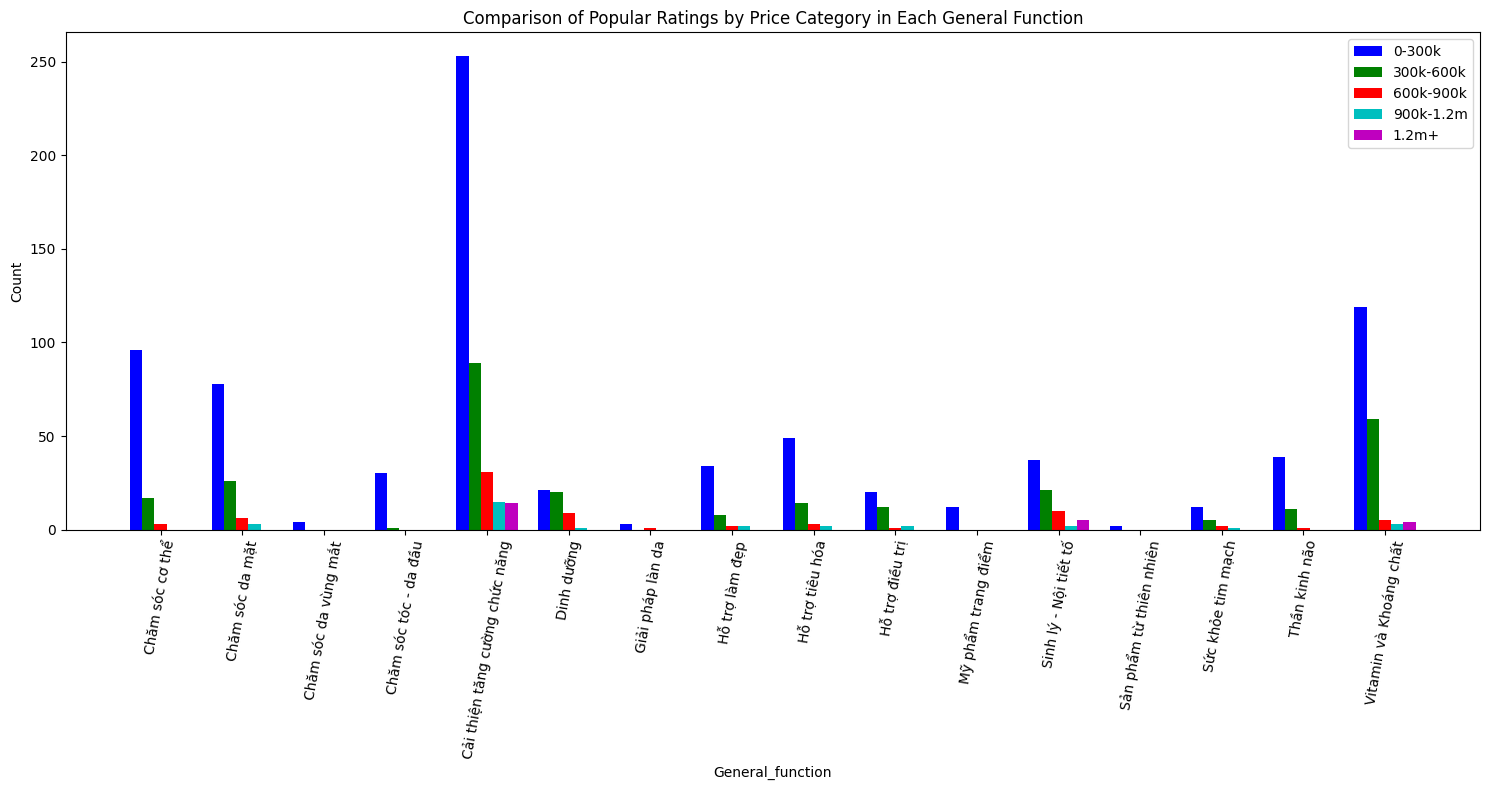

In [18]:
# Add a new column to classify price ranges
bins = [0, 300000, 600000, 900000, 1200000, float('inf')]
labels = ['0-300k', '300k-600k', '600k-900k', '900k-1.2m', '1.2m+']
df['Price_Category'] = pd.cut(df['Price'], bins=bins, labels=labels, right=False)

# Use groupby and agg to calculate the number of 'Popular' in each General_function and Price_Category group
grouped_df = df.groupby(['General_function', 'Price_Category']).agg(
    Popular=('Rating', lambda x: (x != 'unknown').sum())
).reset_index()

# Set up the position of each group of bars
index = np.arange(len(grouped_df['General_function'].unique()))
bar_width = 0.15

# Set up colors for the price ranges
colors = ['b', 'g', 'r', 'c', 'm']

# Set up the plot
fig, ax = plt.subplots(figsize=(15, 8))

# Plot the bars for each price range
for i, label in enumerate(labels):
    bar_data = grouped_df[grouped_df['Price_Category'] == label]
    bar = ax.bar(index + i * bar_width, bar_data['Popular'], bar_width, label=label, color=colors[i])

# Set up the title and labels
ax.set_xlabel('General_function')
ax.set_ylabel('Count')
ax.set_title('Comparison of Popular Ratings by Price Category in Each General Function')
ax.set_xticks(index + bar_width * (len(labels) - 1) / 2)
ax.set_xticklabels(grouped_df['General_function'].unique(), rotation=80)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


#### **To summarize**:
- In the above chart, it can be seen that in any category, there are products priced from 0-300k. This suggests that this is a common price range for customers. 
- The diversity in price ranges within each category is not particularly clear, but it's most evident in the "Function Enhancement", "Vitamins and Minerals", and "Physiology - Hormones" categories. These are the categories with a wide range of prices from low to high, making it easier for customers to choose. Consequently, these might be the categories that pharmacies should focus on in terms of pricing to cater to their customers appropriately.

## **Question 4**

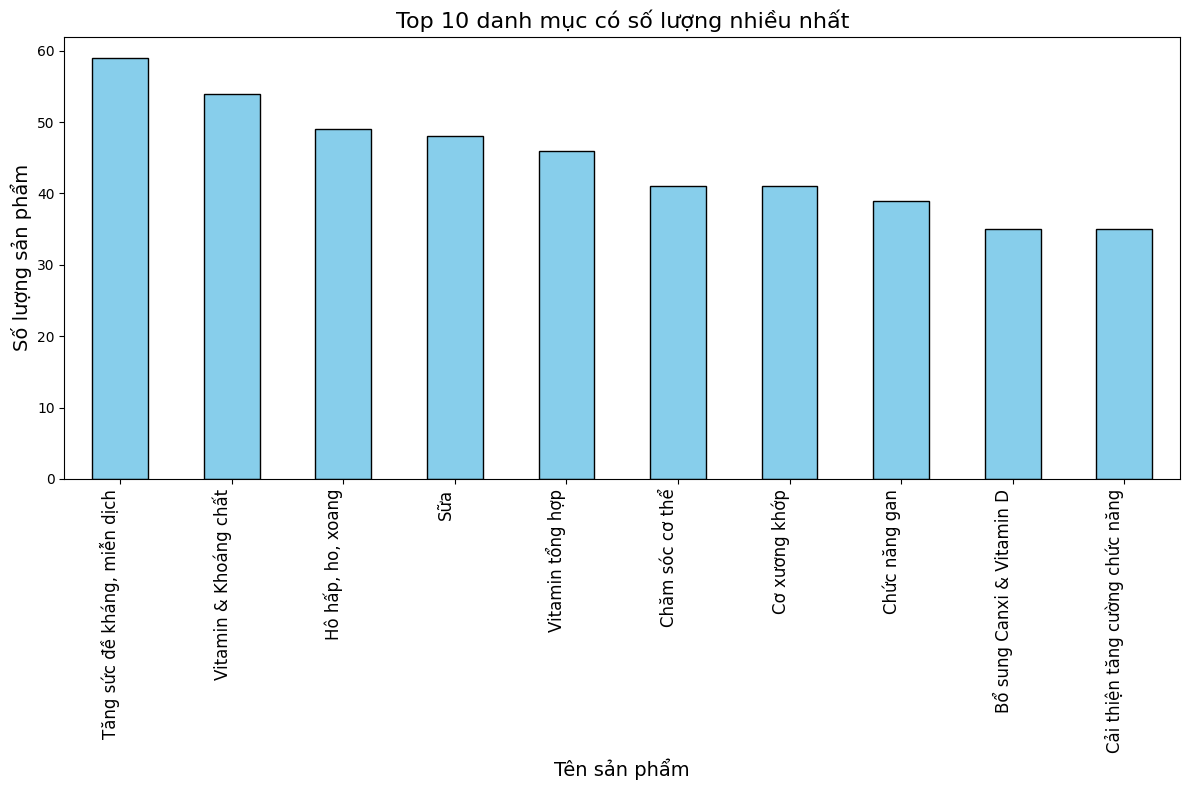

In [19]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Lọc các sản phẩm có Rating >= 0
filtered_df = df[df['Rating'] >= 0]

# Tính toán top 10 sản phẩm có số lượng nhiều nhất
top_products = filtered_df['Category'].value_counts().head(10)

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 categories with the most number', fontsize=16)
plt.xlabel('General funtion', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

#### **To summarize for the first chart**: 
- **Market Overview:**
    - The market for major categories such as immune support, immunity, and vitamins & minerals is highly competitive, as evidenced by their wide diversity and the highest number of products.
    - Meanwhile, other categories, such as Calcium & Vitamin D supplements and functional improvement products, also have a significant number of offerings but have yet to dominate the market.
-  **Market Trends:**
    - The categories with the most diverse and extensive offerings are prominently seen in: immune support, immunity; vitamins & minerals; respiratory, cough, sinus health; dairy products; multivitamins; personal care; musculoskeletal health; liver function; Calcium & Vitamin D supplements; and functional improvement products.

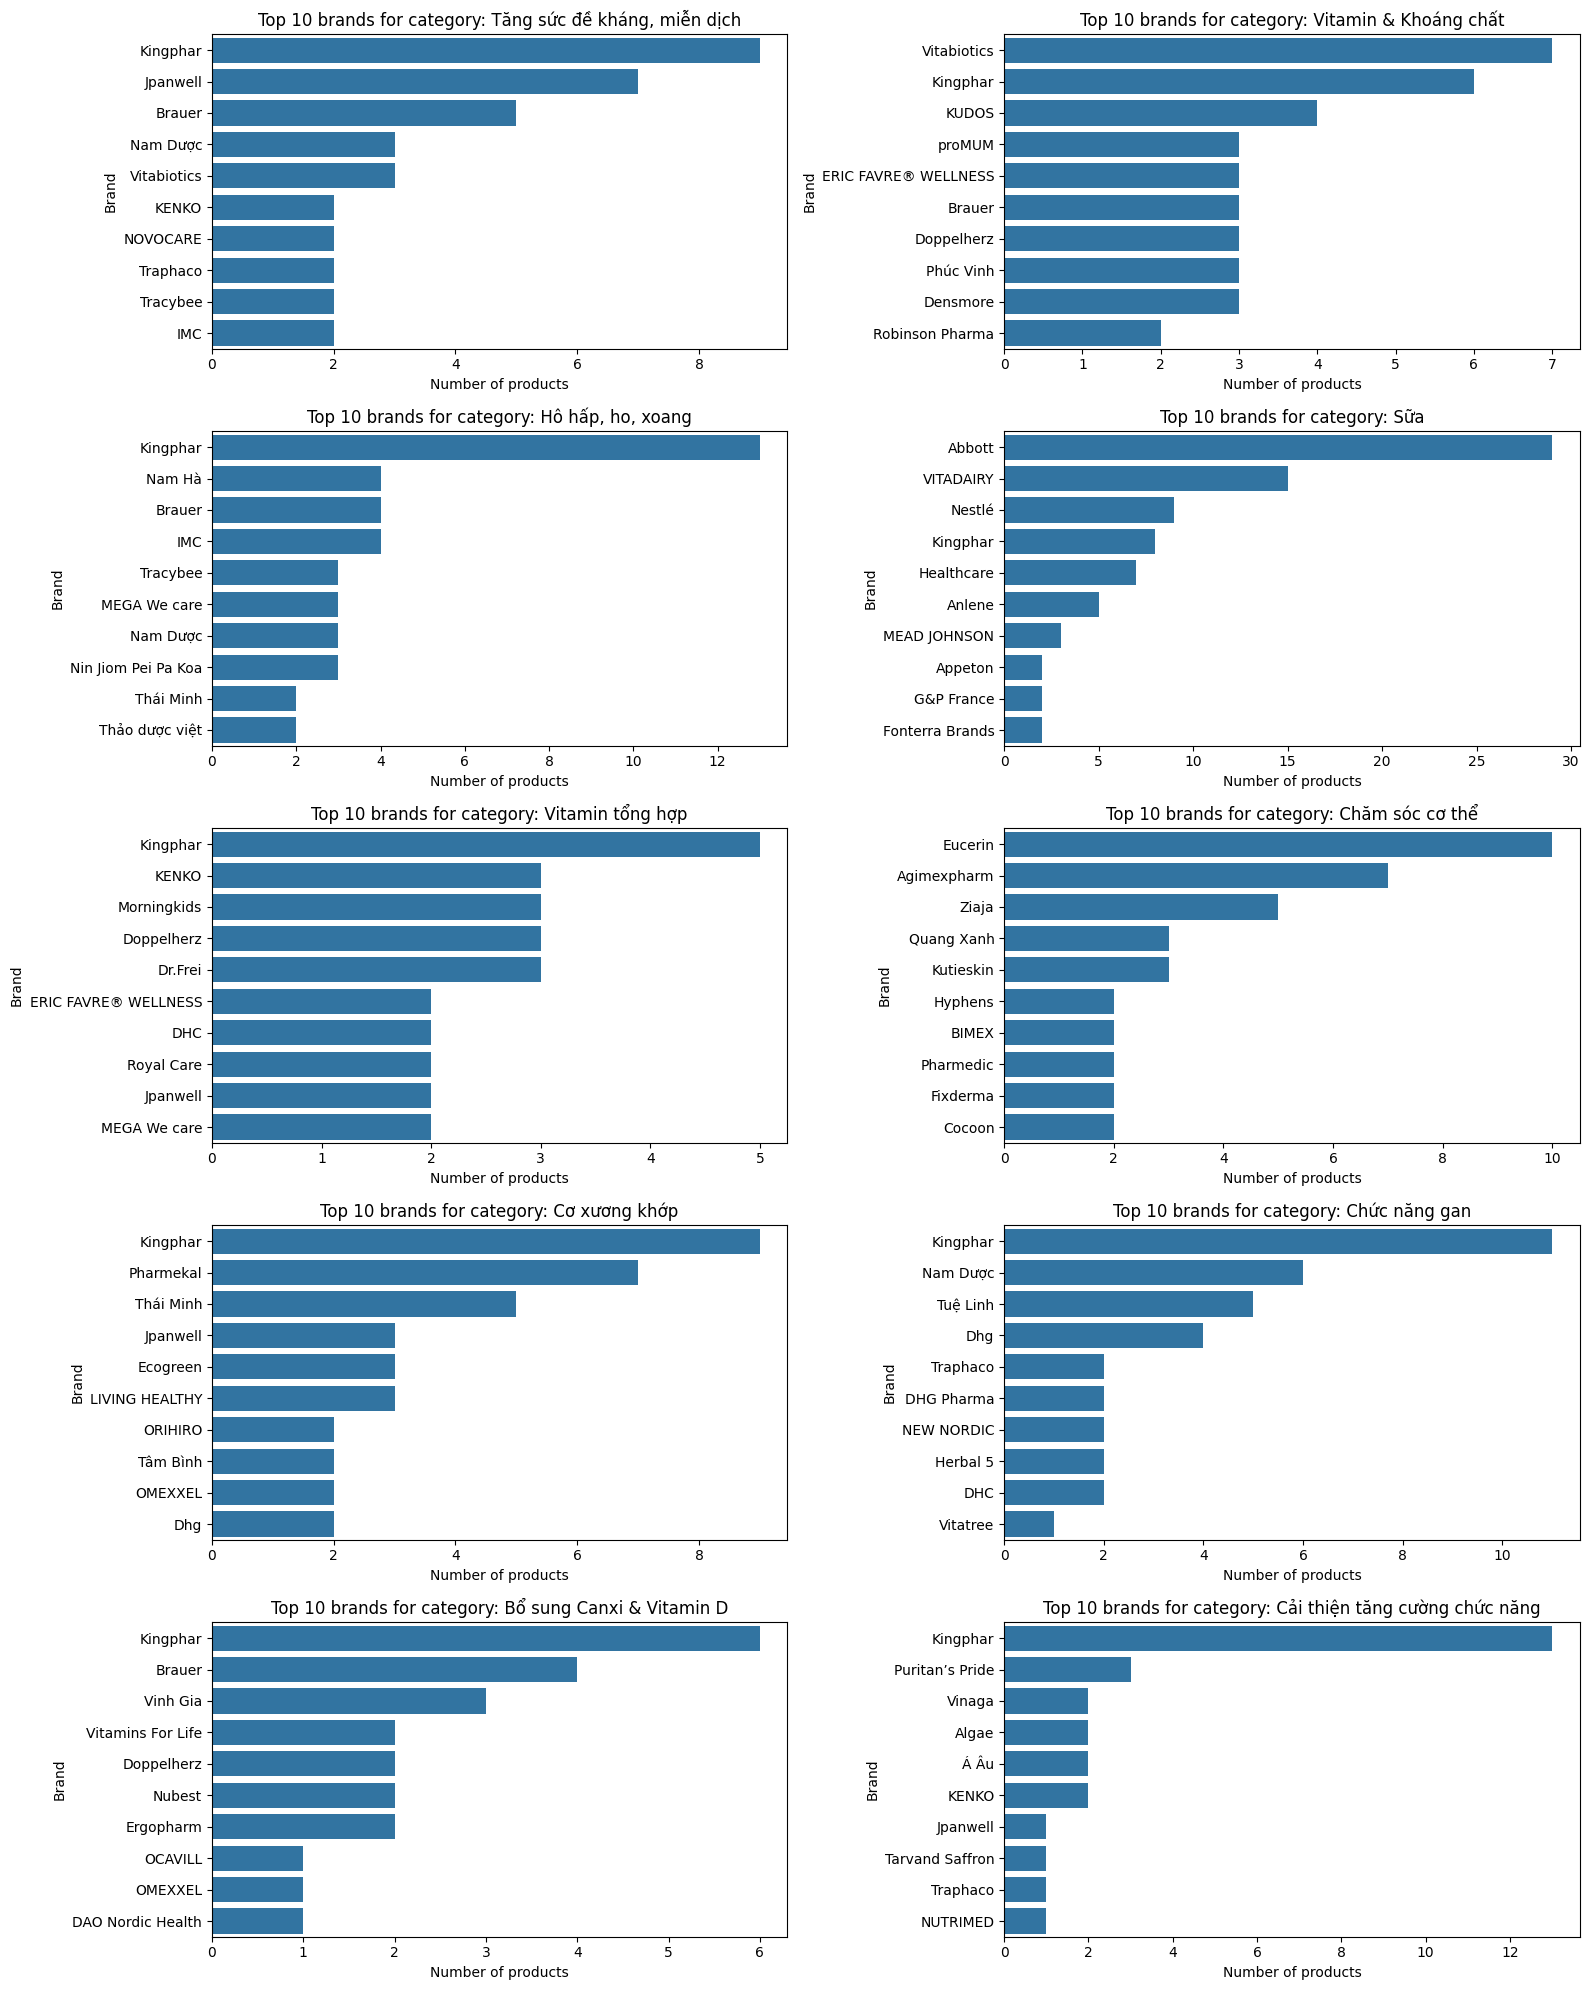

In [20]:
top_products_list = top_products.index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(16, 20)) 
axes = axes.flatten()

# Set the title for the entire figure
fig.suptitle("Top 10 brands for each category", fontsize=16)

for i, product in enumerate(top_products_list):
    product_data = df[df['Category'] == product]
    
    top_brands = product_data['Trademark'].value_counts().head(10)
    
    sns.barplot(
        x=top_brands.values,
        y=top_brands.index,
        ax=axes[i],
        # palette='viridis'
    )

    # Add a title to each subplot
    axes[i].set_title(f"{product[:40]}", fontsize=12)
    axes[i].set_xlabel('Number of products', fontsize=10)
    axes[i].set_ylabel('Brand', fontsize=10)  

# Adjust layout to accommodate the figure title
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the figure title
plt.show()

#### **To summarize for the second chart**: 
- Some categories are clearly dominated by major brands, while others have a more balanced distribution among various brands.
    - Categories with clear dominance:
        - Categories such as respiratory, cough, sinus health; dairy products; personal care; Calcium and Vitamin D supplements; and functional improvement are dominated by major brands like Abbott, Kingphar, and Eucerin. These brands account for the majority of products, as evidenced by their disproportionately tall representative bars.
    - Categories with balanced distribution:
        - Categories such as vitamins & minerals, multivitamins, and musculoskeletal health have a more balanced distribution, with multiple brands appearing and maintaining relatively equal shares.
- Brand Distribution:
	- Brand distribution data:
        -  Some brands like Kingphar, Abbott, and Blackmores are present across multiple categories, showcasing their significant market influence.
        - Smaller brands tend to focus on a few specific categories, with fewer products but remain competitive in their niche markets.

## **Question 5**

<Figure size 1400x800 with 0 Axes>

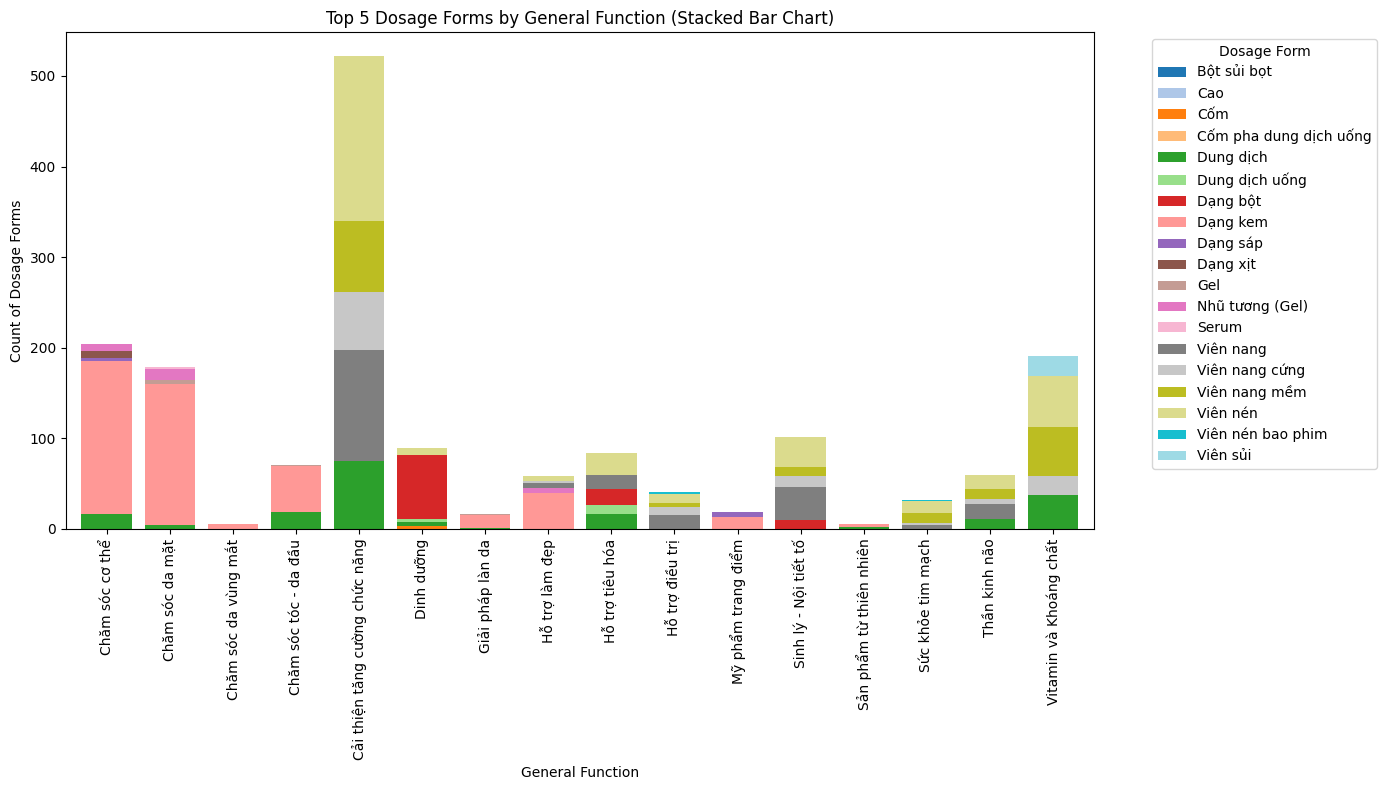

In [21]:
mapping = {
    'Bột': 'Dạng bột',  
    'Dạng bột': 'Dạng bột',
    'Kem': 'Dạng kem',
    'Dạng kem': 'Dạng kem',
}

# Apply mapping to consolidate dosage forms
df['Dosage Form'] = df['Dosage Form'].replace(mapping)

# Step 2: Count the occurrences of each dosage form by category
dosage_counts = df.groupby(['General_function', 'Dosage Form']).size().unstack(fill_value=0)

# Step 3: Filter out the top 5 dosage forms for each category
top_5_dosage = dosage_counts.apply(lambda x: x.nlargest(5).index, axis=1)
filtered_dosage_counts = dosage_counts.apply(lambda x: x.nlargest(5), axis=1)

# Step 4: Visualize the results using a stacked bar chart
plt.figure(figsize=(14, 8))

# Plot stacked bar chart
ax = filtered_dosage_counts.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20', width=0.8)

# Add title and labels
plt.title('Top 5 Dosage Forms by General Function (Stacked Bar Chart)')
plt.xlabel('General Function')
plt.ylabel('Count of Dosage Forms')

# Adjust the position of the X-axis labels and rotate them vertically
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')

# Move the legend outside the plot
plt.legend(title="Dosage Form", bbox_to_anchor=(1.05, 1), loc='upper left')

# Fine-tune the layout and display the plot
plt.tight_layout()
plt.show()


#### **To summarize for the first chart**: 
* Dosage forms such as tablets and capsules are mainly focused on categories related to health improvement (such as enhancing function, vitamins and minerals, hormonal physiology).
* Cream formulations are primarily focused on categories related to skincare and body care.
* Powder formulations are suitable for categories related to nutritional support. => The information in this chart can help consumers make shopping decisions. If users are interested in supporting health inside the body, tablet formulations would be a suitable choice, while for skincare, creams are more common. This narrows down product choices for consumers, helping to save time in product search.

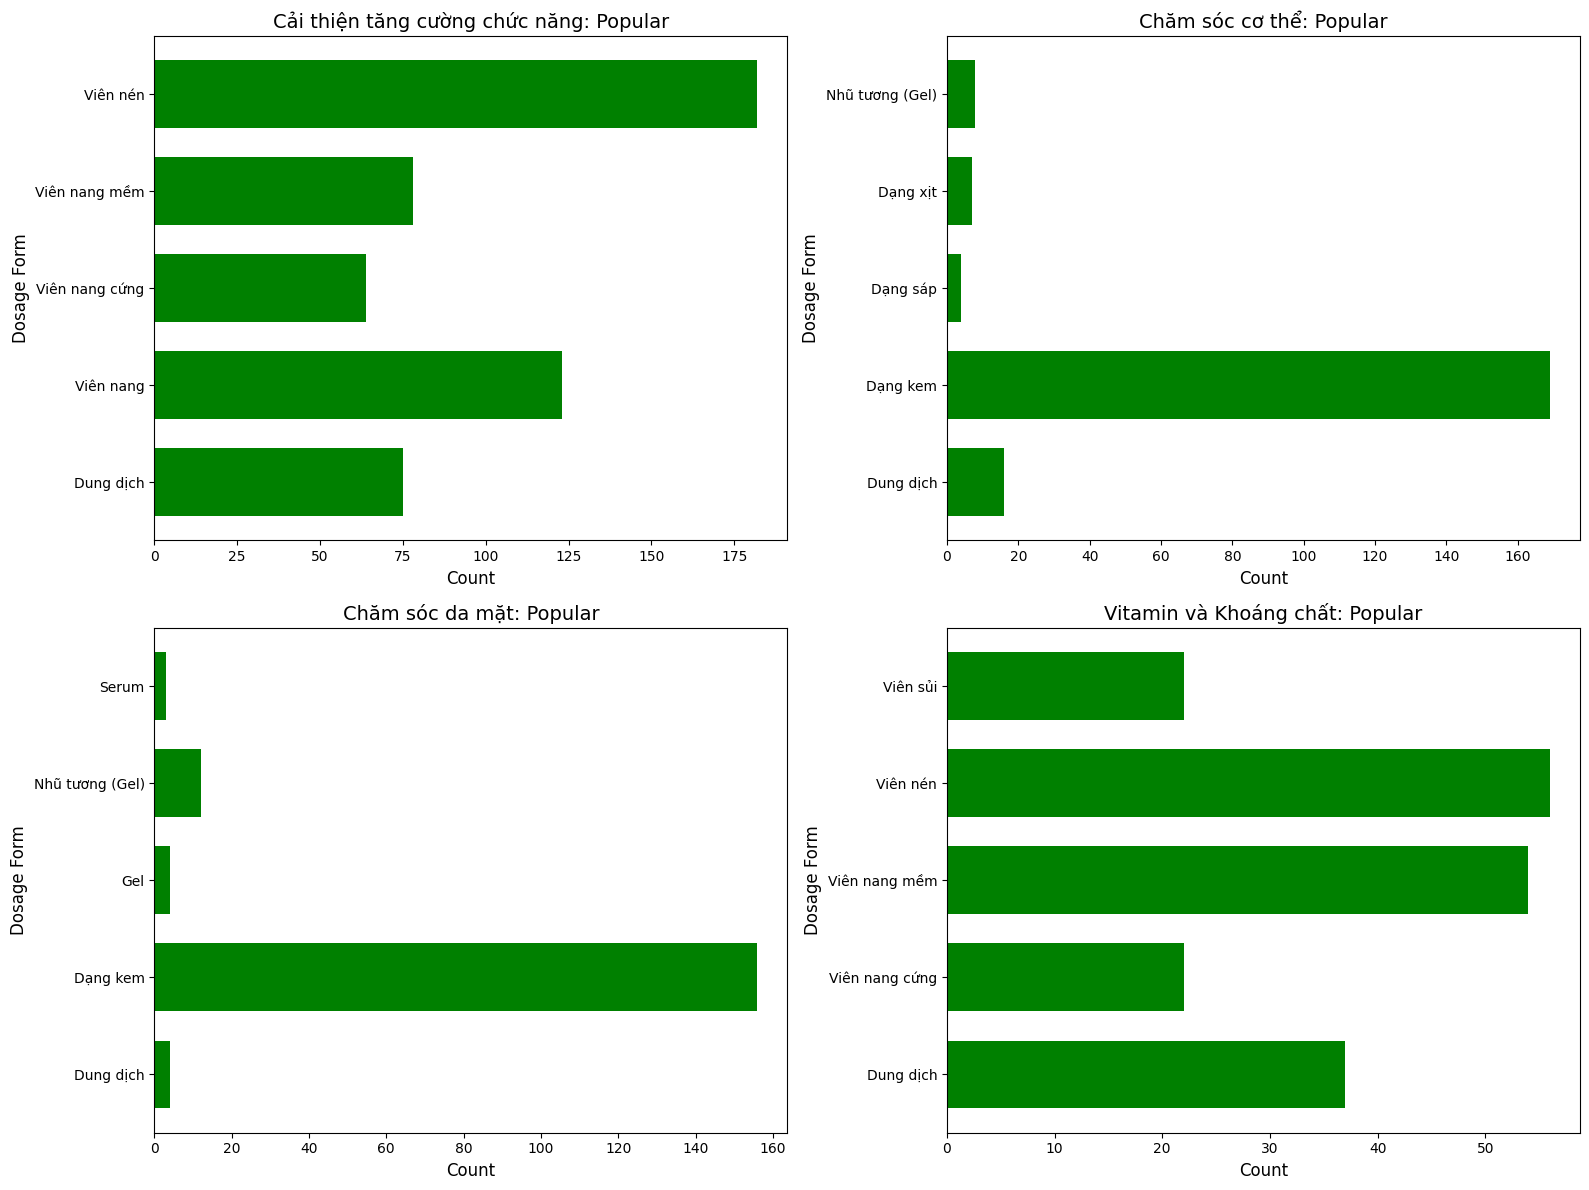

In [22]:
# Prepare 'Popular' data
df['Popular'] = df['Rating'].apply(lambda x: 1 if x != "unknown" else 0)

# Calculate the total 'Popular' count by General_function and Dosage Form
rating_summary = df.groupby(['General_function', 'Dosage Form'])[['Popular']].sum().reset_index()

# Count the occurrences of each dosage form by category
dosage_counts = df.groupby(['General_function', 'Dosage Form']).size().reset_index(name='Count')

# Merge original data to include the 'Price' column in dosage_counts
dosage_counts = pd.merge(dosage_counts, df[['General_function', 'Dosage Form', 'Price']], 
                          on=['General_function', 'Dosage Form'], how='left')

# Calculate the total occurrences for each category and filter the top 4 categories
total_counts_per_category = dosage_counts.groupby('General_function')['Count'].sum().reset_index()
top_4_categories = total_counts_per_category.nlargest(4, 'Count')['General_function']

# Filter data for the top 4 categories
filtered_rating_summary = rating_summary[rating_summary['General_function'].isin(top_4_categories)]

# Visualize the 'Popular' counts
plt.figure(figsize=(16, 12))

for i, category in enumerate(top_4_categories, 1):
    # Filter data by the current category
    category_data = filtered_rating_summary[filtered_rating_summary['General_function'] == category]
    
    # Filter the top 5 most popular dosage forms
    top_5_dosage = category_data.groupby('Dosage Form')['Popular'].sum().nlargest(5).index
    category_data = category_data[category_data['Dosage Form'].isin(top_5_dosage)]
    
    # Set up the plot
    plt.subplot(2, 2, i)
    category_data.set_index('Dosage Form')['Popular'].plot(
        kind='barh', ax=plt.gca(), color='green', width=0.7
    )
    plt.title(f'{category}: Popular', fontsize=14)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Dosage Form', fontsize=12)
    plt.tight_layout()

plt.show()


#### **To summarize**: 
As we can see, categories related to internal health support tend to have a large number of ratings for pill dosage forms, while categories related to skincare and body care have a large number of ratings for cream dosage forms. This suggests that these dosage forms are more popular, trusted, and preferred by consumers in the market. On the other hand, dosage forms with lower rating counts may indicate that they are less experienced by consumers, not as widespread in the market, and may not have gained as much trust. Therefore, consumers can consider and quickly choose the appropriate and suitable dosage form for use.

## **Summarize after making question and visualizing**
- From asking the big question of what factors will affect users' evaluation and purchases. We have obtained 4 attributes which includes **'Country', 'Trademark', 'Price'** and **'Dosage Form'** features. We then clarified the influence of each attribute in each product category. Selecting these four attributes also helps determine the attributes to build the model later.